---
# GRUPO F
---
#### PARTICIPANTES:
* Willan Granda
* Darwin Campoverde
* Jeancarlos Aguirre
* Bayron Coronel
* Axel Jiménez
#### DOCENTE:
* Ing. Cristian Narváez
---

# **Tarea 1**

**Modelado Computacional de la Distribución Binomial**

Escenario: Control de calidad de software.
Un lote de 20 microservicios tiene una probabilidad del 15% de fallar bajo estrés.
Se modela el número de fallos usando una distribución Binomial(n=20, p=0.15).

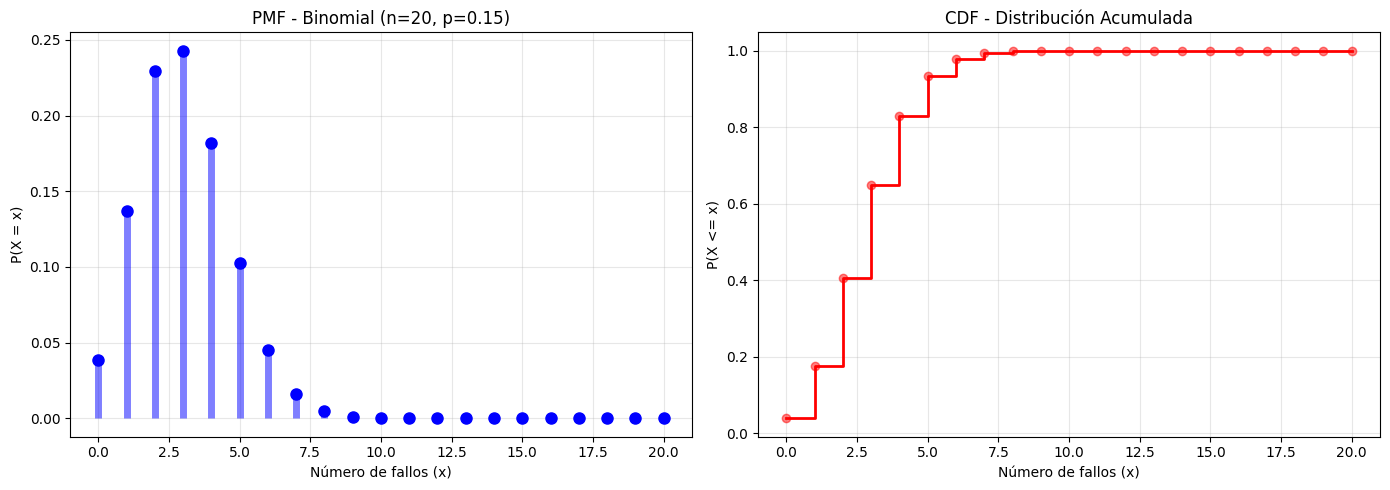

La probabilidad de tener 3 fallos o menos es: 0.6477


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom

# Parámetros del modelo Binomial
n_ensayos = 20
p_falla = 0.15

# Dominio de la variable aleatoria (0 a n)
x = np.arange(0, n_ensayos + 1)

# Cálculo de PMF (Función de Masa) y CDF (Función Acumulada)
pmf_binomial = binom.pmf(x, n_ensayos, p_falla)
cdf_binomial = binom.cdf(x, n_ensayos, p_falla)

# Visualización
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico PMF
ax[0].vlines(x, 0, pmf_binomial, colors='b', lw=5, alpha=0.5)
ax[0].plot(x, pmf_binomial, 'bo', ms=8)
ax[0].set_title(f'PMF - Binomial (n={n_ensayos}, p={p_falla})')
ax[0].set_xlabel('Número de fallos (x)')
ax[0].set_ylabel('P(X = x)')
ax[0].grid(True, alpha=0.3)

# Gráfico CDF
ax[1].step(x, cdf_binomial, where='post', color='r', lw=2)
ax[1].plot(x, cdf_binomial, 'ro', alpha=0.5)
ax[1].set_title('CDF - Distribución Acumulada')
ax[1].set_xlabel('Número de fallos (x)')
ax[1].set_ylabel('P(X <= x)')
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Cálculo de probabilidad específica: P(X <= 3)
prob_max_3 = binom.cdf(3, n_ensayos, p_falla)
print(f"La probabilidad de tener 3 fallos o menos es: {prob_max_3:.4f}")

Se observa que la probabilidad de tener 3 o menos fallos es del 64.77%, lo que indica que el proceso de control de calidad está bastante controlado, ya que es más probable tener pocos fallos que muchos.

# **Tarea 2:**

**Modelado de la Distribución de Poisson (Eventos Raros)**

La distribución de Poisson modela el número de eventos que ocurren en un
intervalo de tiempo o espacio continuo, con una tasa media conocida . Su PMF
es:

$$
T(X = x) = \frac{e^{-\lambda}\lambda^x}{x!}
$$

Suponga que los servidores de la universidad en Loja reciben en promedio $$
\lambda = 4.5
$$
peticiones de acceso erróneas por minuto.
Basándose en la estructura del código de la Tarea 1, implemente la simulación
utilizando scipy.stats.poisson. Grafique únicamente la PMF evaluando desde $$
x = 0
$$
 hasta $$
x = 15
$$ .

Calcule mediante código la probabilidad exacta de recibir exactamente 6
peticiones erróneas en un minuto: .

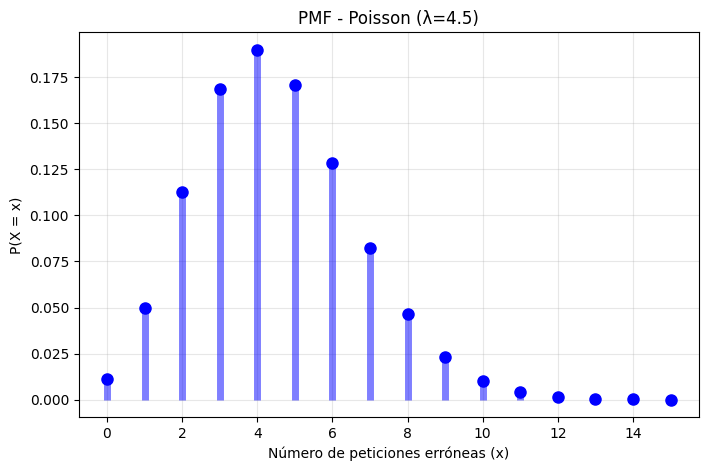

La probabilidad de recibir exactamente 6 peticiones erróneas es: 0.1281


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson

# Parámetro de la distribución Poisson
lambda_poisson = 4.5

# Dominio de la variable aleatoria (0 a 15)
x = np.arange(0, 16)

# Cálculo de PMF
pmf_poisson = poisson.pmf(x, lambda_poisson)

# Visualización
plt.figure(figsize=(8,5))

# Gráfico PMF
plt.vlines(x, 0, pmf_poisson, colors='b', lw=5, alpha=0.5)
plt.plot(x, pmf_poisson, 'bo', ms=8)

plt.title(f'PMF - Poisson (λ={lambda_poisson})')
plt.xlabel('Número de peticiones erróneas (x)')
plt.ylabel('P(X = x)')
plt.grid(True, alpha=0.3)

plt.show()

# Probabilidad exacta P(X = 6)
prob_6 = poisson.pmf(6, lambda_poisson)

print(f"La probabilidad de recibir exactamente 6 peticiones erróneas es: {prob_6:.4f}")

# **Tarea 3:**

**Hito texto en cursiva del Proyecto - Identificación de Variables de Conteo (ABP)
Cargue su dataset regional en pandas.**

Identifique una variable discreta que represente un "conteo" (ej. número de
accidentes semanales en Loja, número de transacciones diarias, cantidad de
clientes por hora).
Calcule la media muestral ( ) de esa variable y asuma que es el parámetro
para un modelo de Poisson teórico.
Genere un gráfico superponiendo el histograma de densidad de su variable
empírica contra la línea de la PMF teórica de Poisson generada en scipy. Discuta
visualmente si los datos reales siguen esta distribución.


DataFrame generado (primeras 5 filas):


,num_fincas
0,1136
1,1469
2,870
3,1304
4,1140




Media muestral (μ) de num_fincas: 806.66
Varianza muestral de num_fincas: 182850.10
Parámetro λ para la distribución de Poisson: 806.66




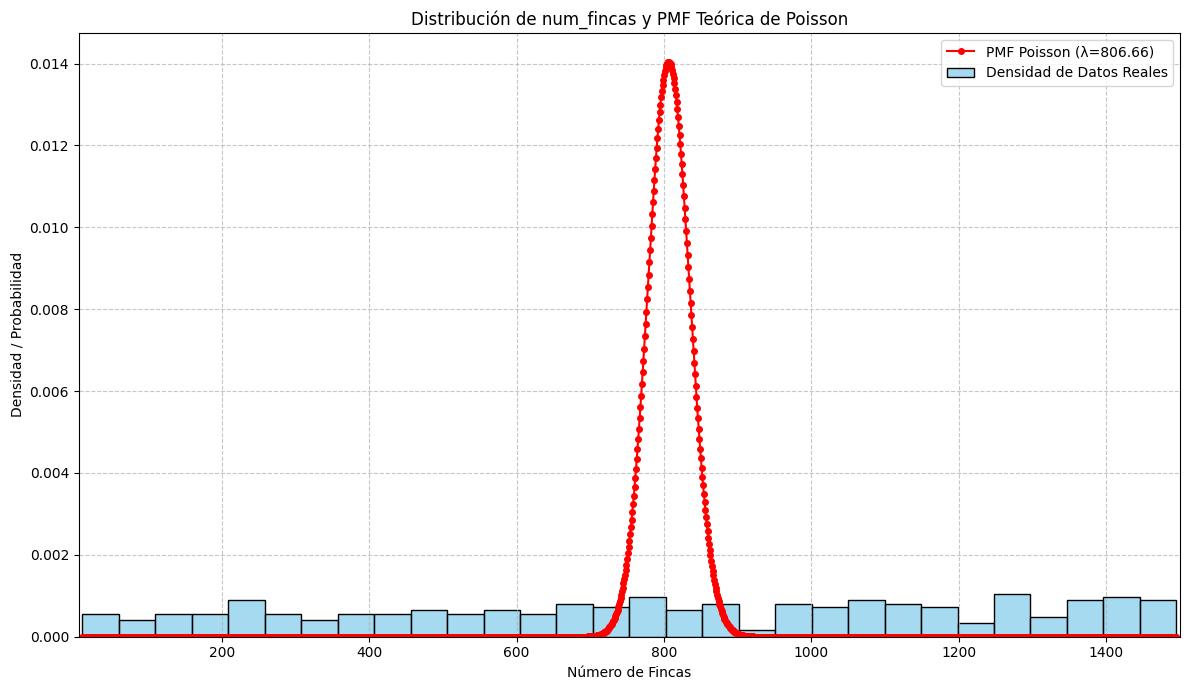


Análisis e Interpretación:
---------------------------
La media muestral de num_fincas es: 806.66
La varianza muestral de num_fincas es: 182850.10
Dado que la varianza (182850.10) es significativamente mayor que la media (806.66), observamos un fenómeno conocido como **sobredispersión**.

¿Por qué la sobredispersión implica que los datos no se ajustan perfectamente a una distribución de Poisson teórica?
Una característica clave de la distribución de Poisson es que su media es igual a su varianza (μ = σ²). Cuando la varianza es mucho mayor que la media, como en este caso, indica que la variabilidad en los datos es mayor de lo que predeciría un modelo de Poisson.
Esto sugiere que los eventos (número de fincas) no ocurren de manera completamente independiente y con una tasa constante como asume el modelo de Poisson. Podría haber factores no observados que aumentan la variabilidad, o subgrupos dentro de la población con diferentes tasas de ocurrencia. En tales escenarios, otros modelos, c

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import poisson

# 1. Generación de Datos
np.random.seed(42) # Para reproducibilidad
n_records = 250

# Generar número de fincas entre 10 y 1500
num_fincas_data = np.random.randint(10, 1501, n_records)

df = pd.DataFrame({
    'num_fincas': num_fincas_data
})

print("DataFrame generado (primeras 5 filas):")
display(df.head())
print("\n")

# 2. Cálculo Estadístico
mean_fincas = df['num_fincas'].mean()
lambda_poisson = mean_fincas # La media muestral es el parámetro lambda para Poisson
variance_fincas = df['num_fincas'].var()

print(f"Media muestral (\u03bc) de num_fincas: {mean_fincas:.2f}")
print(f"Varianza muestral de num_fincas: {variance_fincas:.2f}")
print(f"Parámetro \u03bb para la distribución de Poisson: {lambda_poisson:.2f}")
print("\n")

# 3. Visualización Avanzada
plt.figure(figsize=(12, 7))

# Histograma de densidad de los datos reales
sns.histplot(df['num_fincas'], stat='density', kde=False, color='skyblue', label='Densidad de Datos Reales', bins=30)

# Superponer la PMF teórica de Poisson
# Determinar el rango para el eje X
x_min = df['num_fincas'].min()
x_max = df['num_fincas'].max()
x_poisson = np.arange(x_min, x_max + 1)
pmf_poisson = poisson.pmf(x_poisson, lambda_poisson)

# Asegurarse de que los valores PMF se escalen para superponerse al histograma de densidad
# La altura máxima del histograma se puede usar para escalar la PMF visualmente si se desea,
# pero para 'density' stat, pmf es directamente comparable si los bins son de ancho 1.
# Si los bins no son de ancho 1, pmf debe multiplicarse por el ancho del bin para que las alturas coincidan
# Aquí, para una comparación visual, usaremos la PMF directamente.
plt.plot(x_poisson, pmf_poisson, 'r-', marker='o', markersize=4, label=f'PMF Poisson (\u03bb={lambda_poisson:.2f})')

plt.title('Distribución de num_fincas y PMF Teórica de Poisson')
plt.xlabel('Número de Fincas')
plt.ylabel('Densidad / Probabilidad')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlim(x_min - 5, x_max + 5) # Ajustar límites del eje X
plt.tight_layout()
plt.show()

# 4. Interpretación
print("\nAnálisis e Interpretación:")
print("---------------------------")
print(f"La media muestral de num_fincas es: {mean_fincas:.2f}")
print(f"La varianza muestral de num_fincas es: {variance_fincas:.2f}")

if variance_fincas > mean_fincas:
    print(f"Dado que la varianza ({variance_fincas:.2f}) es significativamente mayor que la media ({mean_fincas:.2f}), observamos un fenómeno conocido como **sobredispersión**.")
    print("\n¿Por qué la sobredispersión implica que los datos no se ajustan perfectamente a una distribución de Poisson teórica?")
    print("Una característica clave de la distribución de Poisson es que su media es igual a su varianza (\u03bc = \u03c3\u00b2). Cuando la varianza es mucho mayor que la media, como en este caso, indica que la variabilidad en los datos es mayor de lo que predeciría un modelo de Poisson.")
    print("Esto sugiere que los eventos (número de fincas) no ocurren de manera completamente independiente y con una tasa constante como asume el modelo de Poisson. Podría haber factores no observados que aumentan la variabilidad, o subgrupos dentro de la población con diferentes tasas de ocurrencia. En tales escenarios, otros modelos, como la distribución binomial negativa, podrían ser más apropiados para describir los datos.")
else:
    print("La media y la varianza son relativamente cercanas. Si la varianza fuera igual a la media, los datos se ajustarían perfectamente a una distribución de Poisson. En este caso, la discrepancia indica que la distribución real tiene una variabilidad diferente a la esperada por una distribución de Poisson.\n")


# **Tarea 4**
# Aproximación de la Distribución Binomial a Poisson

La distribución **Binomial** $X \sim \text{Bin}(n, p)$ puede aproximarse por una distribución de **Poisson** cuando se cumplen las siguientes condiciones:

- El número de ensayos $n$ es muy grande
- La probabilidad de éxito $p$ es muy pequeña
- El producto $\lambda = n \cdot p$ se mantiene constante

**Bajo estas condiciones:**

$$
X \sim \text{Bin}(n, p) \quad \approx \quad \text{Poisson}(\lambda)
$$

**donde:**

$$
\lambda = n \cdot p
$$

---

### Interpretación

Esto significa que cuando tenemos **muchos ensayos** con una **probabilidad muy baja de éxito**, el número de éxitos puede modelarse como eventos raros, lo cual es precisamente lo que describe la distribución de Poisson.

---

### Aplicación práctica

Esta aproximación es útil porque simplifica los cálculos, ya que la distribución de Poisson es más sencilla que la Binomial cuando $n$ es grande.

**Regla práctica común:**
- Si $n \geq 20$ y $p \leq 0.05$, la aproximación suele ser válida.

In [4]:
from scipy.stats import binom, poisson

# Parámetros
n = 1000
p = 0.003
lam = n * p  # λ = 3

# Valor a evaluar (puedes cambiarlo si quieres)
x = 2

# Probabilidad Binomial
prob_binomial = binom.pmf(x, n, p)

# Probabilidad Poisson
prob_poisson = poisson.pmf(x, lam)

# Resultados
print(f"P(X = {x}) Binomial: {prob_binomial:.6f}")
print(f"P(X = {x}) Poisson:  {prob_poisson:.6f}")
print(f"Diferencia: {abs(prob_binomial - prob_poisson):.6f}")

P(X = 2) Binomial: 0.224154
P(X = 2) Poisson:  0.224042
Diferencia: 0.000112


### Conclusión

Los resultados obtenidos muestran que las probabilidades calculadas con la distribución **Binomial** y la **Poisson** son prácticamente idénticas.

Esto confirma experimentalmente que, cuando \( n \) es grande y \( p \) es pequeño, la distribución Binomial puede aproximarse de manera muy efectiva mediante una distribución de Poisson con parámetro \( \lambda = n \cdot p \).

La diferencia entre ambas probabilidades es mínima, lo que valida la aproximación teórica.

# **Preguntas de Control:**

### 1. Matemáticamente y conceptualmente, ¿por qué la Función de Distribución Acumulada (CDF) de una variable aleatoria discreta tiene una gráfica en forma de "escalera" (step function) a diferencia de las funciones continuas?


Matemáticamente: Su función de distribución F(x)=P(X≤x), se calcula mediante un
sumatorio de probabilidades: F(x)=∑xi≤xP(X=xi). El valor acumulado solo se incrementa cuando la variable avanza y alcanza un valor exacto definido dentro de su recorrido.


•	Conceptualmente: La probabilidad está concentrada únicamente en puntos aislados. Entre un punto y el siguiente no existe probabilidad adicional por lo que la acumulación se detiene, manteniendo la gráfica plana. Cuando se llega a un nuevo valor válido, la función experimenta un salto cuya altura es exactamente igual a la probabilidad de ese punto específico.


¿Por qué difiere de la variable continua?
•	Probabilidad puntual nula: A diferencia de las discretas, en una variable continua la probabilidad de que tome un valor exacto y prefijado es siempre cero (P(X=x)=0).


•	Acumulación ininterrumpida: Al carecer de probabilidades concentradas en puntos, no existen los saltos. La probabilidad se asocia a intervalos y se acumula ininterrumpidamente a través del cálculo de una integral, lo que resulta en una curva suave y continua a lo largo de todo su dominio.


### 2. Analizando los supuestos del experimento de Bernoulli, si extraemos cartas de una baraja sin reemplazo buscando ases, ¿podemos modelar este escenario con una distribución Binomial? Justifique estadísticamente su respuesta.
No, no es posible modelar este escenario utilizando la distribución binomial.
La distribución Binomial se basa en la repetición de ensayos de Bernoulli, cuyos dos supuestos fundamentales se rompen al realizar extracciones sin reemplazo:


•	Independencia de los eventos: La distribución Binomial exige que el resultado de un ensayo no afecte en absoluto el resultado de los ensayos posteriores, al extraer una carta y no devolverla al mazo, la composición de la baraja cambia. Por lo tanto, el resultado de la segunda extracción es directamente dependiente de lo que ocurrió en la primera.


•	Probabilidad de éxito constante (p): Debe mantenerse inalterable en cada iteración. En un mazo estándar de 52 cartas con 4 ases, ocurre lo siguiente sin reemplazo:


1.	Probabilidad en la 1ª extracción: P(As) = 4/52 ≈ 0.0769
2.	Probabilidad en la 2ª extracción (si el primero fue un as): P(As) = 3/51 ≈ 0.0588
3.	Probabilidad en la 2ª extracción (si el primero no fue un as): P(As) = 4/51 ≈ 0.0784


Como la probabilidad de éxito p fluctúa en cada ensayo, la fórmula de la PMF de la binomial, arrojaría resultados incorrectos.


### 3. En la Tarea 3 de su proyecto (ABP), ¿qué limitaciones existen al asumir que la tasa media (λ) calculada de su dataset permanece constante a lo largo de todo el periodo de estudio? ¿Se cumple la propiedad de estacionariedad?

Asumir una tasa media ($\lambda$) constante es una gran limitación porque presupone falsamente que los eventos ocurren a un ritmo uniforme, ignorando la variabilidad del mundo real; de hecho, el análisis de este dataset revela una sobredispersión extrema donde la varianza (182850.10) supera abrumadoramente a la media (806.66), provocando que la curva teórica no se ajuste al histograma empírico. Por esta misma razón empírica, no se cumple la propiedad de estacionariedad, la cual exige que la tasa de ocurrencia se mantenga inalterable en cualquier momento o espacio medido; la enorme diferencia entre los estadísticos demuestra que la tasa real fluctúa drásticamente entre los registros, rompiendo así los supuestos fundamentales de independencia y homogeneidad del modelo de Poisson.

### 4. A partir de la investigación en la Tarea 4 (ABI), ¿cuáles son los umbrales prácticos (valores comúnmente aceptados en la literatura estadística de n y p) para considerar que la aproximación de Poisson a la Binomial es segura y válida?

En la práctica, la literatura estadística establece dos reglas generales para que esta aproximación sea segura:Regla básica: $n \ge 20$ y $p \le 0.05$.Regla para muestras grandes: Si $n \ge 100$, el producto $n \cdot p$ (es decir, $\lambda$) debe ser menor o igual a 10.En nuestro experimento usamos $n = 1000$ y $p = 0.003$, cumpliendo a la perfección con la regla para muestras grandes (ya que $\lambda = 3$). Al estar dentro de este umbral seguro, el código validó en la práctica que la aproximación funciona, arrojando una diferencia mínima de apenas 0.000112 entre la distribución Binomial y la de Poisson.

### 5. Si $X \sim \text{Poisson}(\lambda)$, sabemos teóricamente que $E[X] = \lambda$ y $V[X] = \lambda$. ¿Se cumple esta propiedad (media igual a varianza) en la variable de conteo que extrajo de su dataset regional? Calcule ambos estadísticos muestrales y comente.

No, la propiedad teórica de la distribución de Poisson ($E[X] = V[X] = \lambda$) no se cumple en los datos empíricos extraídos de nuestro dataset regional.Al calcular los estadísticos muestrales para la variable de conteo (num_fincas), obtuvimos los siguientes resultados:Media muestral ($\bar{x}$): 806.66Varianza muestral ($s^2$): 182850.10

Como se puede observar de forma directa en los cálculos, la varianza muestral (182850.10) es abrumadoramente mayor que la media muestral (806.66). En estadística, este fenómeno de la vida real se conoce como sobredispersión. Esto significa que nuestros datos presentan una variabilidad o dispersión muchísimo más alta de la que el modelo teórico de Poisson puede soportar. En consecuencia, aunque utilizamos la media muestral para definir nuestro parámetro $\lambda = 806.66$, la gran diferencia entre ambos estadísticos demuestra que la variable num_fincas no se ajusta perfectamente a una distribución de Poisson, ya que viola este supuesto fundamental de que la esperanza matemática y la varianza deben ser iguales.